#### SPA6330: Artificial Intelligence and Machine Learning
#### MO: Dr Linda Cremonesi

# Final Project - Predicting House Prices in England

<hr style="border:2px solid gray">

## Problem formulation:

The aim of this report is to predict the median house price for different areas in England using a linear regression model. House prices have been volatile in recent years. From 2024 to 2025, there was a 4.9% increase in average house prices, and in 2021, prices fluctuated by nearly 10% within a single month [2]. Therefore, predicting house prices provides valuable guidance for buyers, investors, and policymakers to give a clear baseline estimate of house prices in an area given how dynamic they can be. 

The dataset used in this project, HousingEngland.csv [1], contains approximately 33,000 entries, each corresponding to a specific area. Each entry includes nine features: a unique geography code, geographic coordinates (latitude and longitude), population size and density, number of households, number of bedrooms and total rooms, and the average income of the area. The target variable is the median house price.

As this is a regression problem, a linear regression model will be used as they are effective at highlighting any clear trends in continuous data and to provide results that are more easily interpretable compared to more complex models. Furthermore, both ridge and lasso regression techniques will be used and evaluated in order to better understand which features are important as well as to prevent overfitting.

## Data preparation and feature engineering:

In [1]:
#IMPORTS
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib.patches as mpatches
from matplotlib import colors
from matplotlib.lines import Line2D

from scipy import stats
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model 
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV, LassoCV 

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder 
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_predict, cross_validate, cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score, make_scorer, mean_absolute_error
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline



import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning) #suppresses convergence warnings, simply for formatting purposes

To begin, the raw housing dataset is cleaned to ensure that the models would not be misled by invalid or extreme data points. Given that the dataset also included entries with values like 0 or 1,000,000 for house prices, which are unrealistic or serve as placeholders due to spreadsheet limits, these were removed. Retaining such values could severely distort the regression line and undermine the model's ability to generalise. The dataset was also checked for NaN values, however no missing values were detected so none were removed to avoid redundancy. These are all shown in the out of the code below. The proportion of missing values was low enough to justify complete row removal without compromising the integrity of the dataset.

Feature Engineering then begins to create more useful features for the model to utilise. A Feature data frame was made by dropping median house price (the target) and geography code (a feature that acts as an identifying key and doesn't provide actual descriptive data about the instance). Then two new features were engineered: average bedrooms per household and average rooms per household. These new features provide a more detailed view of varying household sizes across the areas instead of a blanket view of how many rooms are present in total. Finally the target data frame was set up using median house price.

In [2]:
#Set up feature Data frames and remove problematic instances
features = pd.read_csv('HousingEngland.csv') #reads the file into the variable features
print('There are {} NaN values in this spreadsheet'.format(features.isna().sum().sum())) #counts the number of NaN values in the data set
print('There are {} instances with a value of zero or 1000000 in one of their features'.format((features == 0.0).sum().sum()+(features == 1000000).sum().sum()))#counts the number of cells with a value of 0
features=features[(features != 0).all(axis=1)] #removes all instances that have a cell that equals 0
print('There are {} instances with a value of zero or 1000000 in one of their features after dropping'.format((features == 0.0).sum().sum())) #checks for cells that contain a 0 again
features=features[(features['median house price'] != 1000000)] #removes all instances that have a cell that equals 1000000 (the maximum allowed house price)
features2= features.drop(columns=['median house price', 'geography code']) #drops the target and unnecessary columns from features data frame

#Engineering new features 
features2['Average Bedrooms']=features2['total rooms']/features2['households']
features2['Average Rooms']=features2['total bedrooms']/features2['households']

#set up targets
initial_targets = features['median house price']


There are 0 NaN values in this spreadsheet
There are 716 instances with a value of zero or 1000000 in one of their features
There are 0 instances with a value of zero or 1000000 in one of their features after dropping


A correlation matrix was generated to assess multicollinearity. Features that show extremely high correlation could be problematic if a simple linear model is used without regularisation. Removing highly correlated features would help reduce redundancy, simplify the model, and avoid instability in coefficient estimation for the base linear model. However, these features will not be removed in order to better highlight the effect Ridge and Lasso regression have, as they are (in part) designed to deal with multicollinearity. The correlation matrix below shows a particularly high correlation between total bedrooms and total rooms as well as average bedrooms and average rooms. 

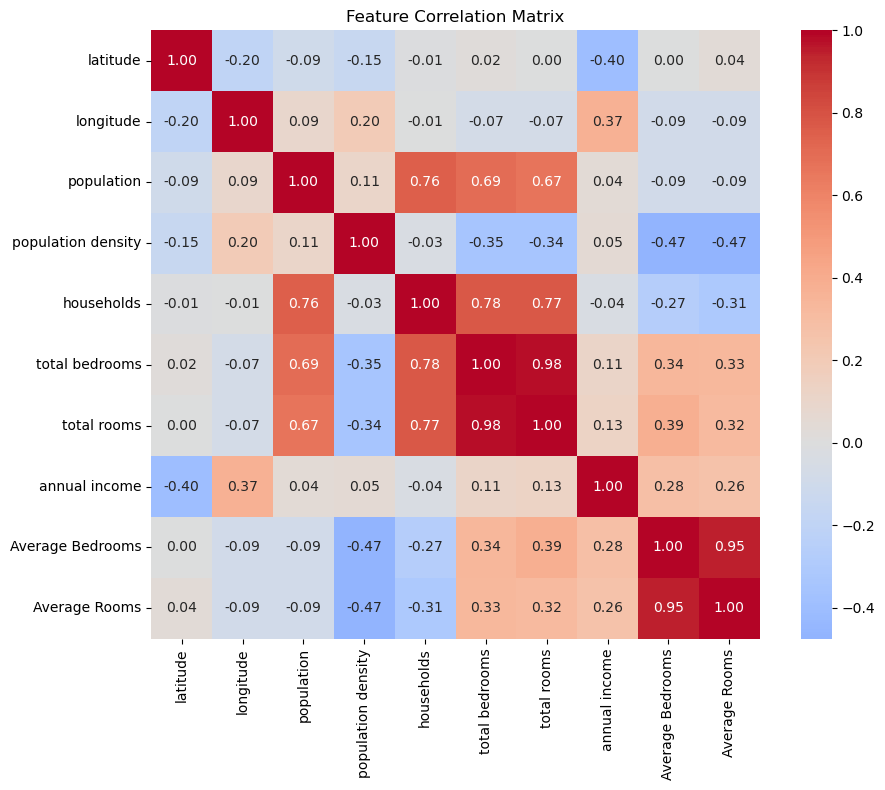

In [3]:
#creates correlation matrix
corr_matrix = features2.corr()
#plots matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In order to illustrate the overall distribution of each feature, multiple histograms have been created in order to illustrate where outliers may lie as well as a table showing the statistical information of the current data set.

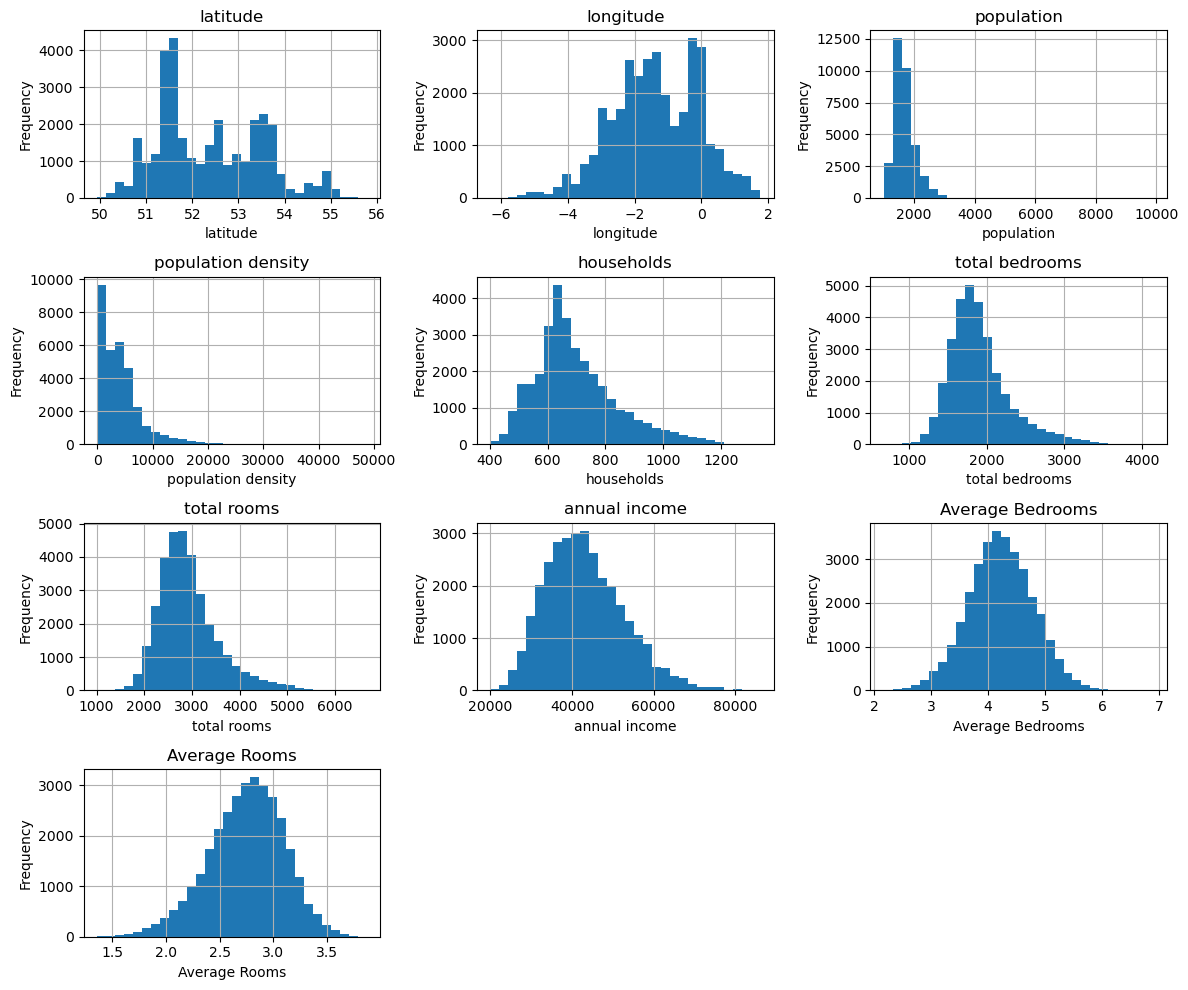

In [4]:
# Create histograms
axes = features2.hist(figsize=(12, 10), bins=30)

# Loop through each subplot to set labels
for ax in axes.flatten():
    ax.set_xlabel(ax.get_title())     # Set x-label to the feature name
    ax.set_ylabel("Frequency")        # Set consistent y-label

plt.tight_layout()
plt.show()

In [5]:
#Statistical Information about the current feature set
features2.describe()

,latitude,longitude,population,population density,households,total bedrooms,total rooms,annual income,Average Bedrooms,Average Rooms
count,32368.000000,32368.000000,32368.000000,32368.000000,32368.000000,32368.000000,32368.000000,32368.000000,32368.000000,32368.000000
mean,52.367697,-1.355876,1672.440651,4197.480907,698.552274,1902.667975,2926.943123,43210.235418,4.220997,2.746187
std,1.131019,1.303542,343.101396,4090.608251,142.964323,398.171446,634.431439,9565.800336,0.571090,0.351089
min,49.935546,-6.314363,996.000000,2.300000,402.000000,672.000000,1013.000000,20000.000000,2.168067,1.361163
25%,51.474211,-2.228759,1445.000000,1184.450000,605.000000,1641.000000,2500.000000,36200.000000,3.841014,2.522338
50%,52.197717,-1.393982,1608.000000,3448.600000,669.000000,1832.000000,2820.000000,42300.000000,4.211689,2.770202
75%,53.379330,-0.264004,1834.000000,5683.125000,772.000000,2075.000000,3217.000000,49300.000000,4.600906,2.994069
max,55.784110,1.757414,9899.000000,48672.800000,1336.000000,4150.000000,6666.000000,86100.000000,6.897059,3.869654


Judging by these distributions, there are clear outliers across multiple features, notably in population and population density. Outliers were addressed using Z-score filtering. A Z-score threshold of 3 was chosen, meaning any data point with a value more than three standard deviations from the mean was considered an outlier and removed. This approach helps mitigate the influence of extreme values that could skew the regression results, especially in linear models which are highly sensitive to such data points. The same histograms and statistical description table have been produced to show the changes.

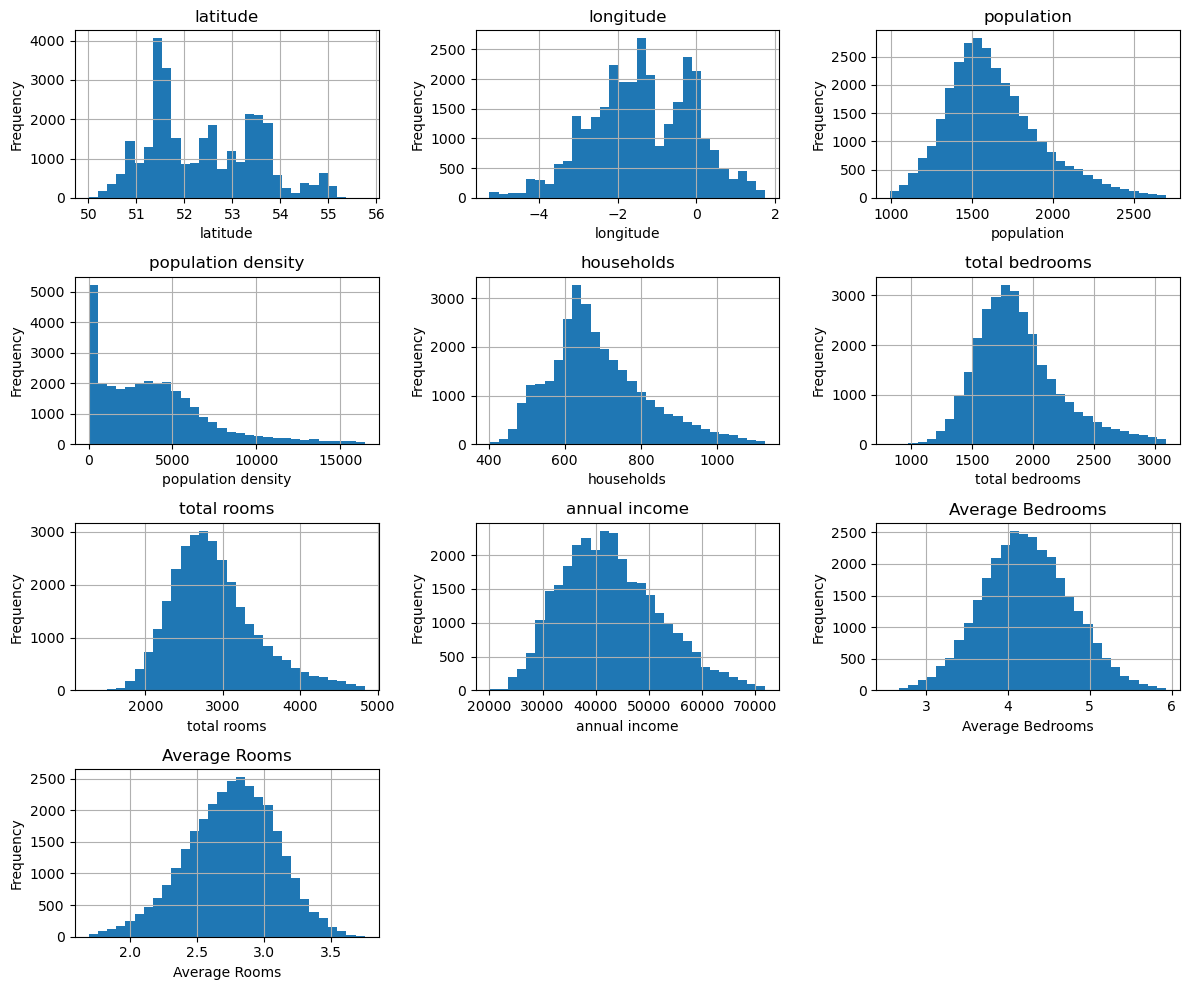

In [6]:
#Remove instances that contain cells that are three standard deviations away from their respective means
z_scores = np.abs(features2.apply(stats.zscore))
final_features = features2[(z_scores < 3).all(axis=1)]

#plot each histogram again to show the distribution 
axes = final_features.hist(figsize=(12, 10), bins=30)

# Loop through each subplot to set labels
for ax in axes.flatten():
    ax.set_xlabel(ax.get_title())     # Set x-label to the feature name
    ax.set_ylabel("Frequency")        # Set consistent y-label


plt.tight_layout()
plt.show()

In [7]:
#again showing Statistical Information about the current feature set
final_features.describe()

,latitude,longitude,population,population density,households,total bedrooms,total rooms,annual income,Average Bedrooms,Average Rooms
count,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000
mean,52.393242,-1.376337,1640.502203,3882.260289,687.775779,1879.687788,2889.639320,42865.220965,4.232418,2.755319
std,1.133673,1.292929,293.018406,3287.297101,128.876074,347.611545,556.402936,9221.109804,0.540258,0.332122
min,50.002141,-5.265967,996.000000,2.300000,402.000000,826.000000,1269.000000,20000.000000,2.559434,1.692982
25%,51.476691,-2.242136,1438.000000,1203.450000,603.000000,1643.000000,2501.000000,36000.000000,3.859196,2.536489
50%,52.260439,-1.428147,1595.000000,3412.900000,664.000000,1827.500000,2810.000000,42000.000000,4.215503,2.773259
75%,53.394195,-0.304426,1802.000000,5545.750000,760.000000,2052.000000,3184.000000,48900.000000,4.595973,2.991102
max,55.757065,1.757414,2701.000000,16463.700000,1127.000000,3096.000000,4830.000000,71900.000000,5.933126,3.747495


Roughly 6% of instances were removed using this method which is not significant enough to affect the overall data set. Finally, the features and targets data frames have their indexes matched and reset. 

In [8]:
final_targets = initial_targets[final_features.index] #matches index with final features
final_targets.columns=['median house price']#renames the column of targets
#Resets the numbering of the data frame indexes
final_features = final_features.reset_index(drop=True)
final_targets = final_targets.reset_index(drop=True)

In order to check the overall distribution of targets haven't been significantly affected by these changes, a final statistical check is performed. The outputs below show there being no significant changes, confirming no bias caused directly by the data preparation carried out. Therefore, the data can be split into train and test sets. A random state of 42 is used throughout for consistency.  

In [9]:
#Initial targets stat info
initial_targets.describe()

count     32368.000000
mean     305633.247528
std      166144.874107
min       26500.000000
25%      182250.000000
50%      268412.500000
75%      390500.000000
max      998750.000000
Name: median house price, dtype: float64

In [10]:
#Final targets stat info
final_targets.describe()

count     30412.000000
mean     299836.541793
std      161086.055456
min       26500.000000
25%      180000.000000
50%      264875.000000
75%      382500.000000
max      996500.000000
Name: median house price, dtype: float64

In [11]:
#Splits the data frames into train and test sets
Xtrain, Xtest, ytrain, ytest = train_test_split(final_features,final_targets,random_state=42)
#renames ytrain columns
ytrain.columns=['median house price']

## Model selection and training: 

The objective of this section was to train multiple regression models to establish a performance baseline and observe how regularisation affects results. Three models were selected. The first was a Linear model which served as the baseline model. Linear regression is a statistical method used to model the relationship between a set of input features and a target output variable. It does this by fitting a straight line through the data that best captures this relationship. The model assumes the target variable can be predicted using a linear combination of the input features: 
$$ y = \theta_0 + \theta_1 x_1 + ... + \theta_N x_N $$where y is the target, θ₀ is the intercept, θᵢ are the coefficients and xᵢ represents the i-th predictor variable.
​While simple and interpretable, it is prone to overfitting if too many features are included and to underfitting when the underlying relationships in the data are too complex to be captured by a linear approximation. The other models chosen were also linear models but utilising different types of regularisation techniques in order to penalise overly large coefficients. The first is Ridge Regression (L2 Regularisation). This technique involves penalising large coefficients by adding the square of each coefficient's magnitude to the loss function. This reduces but dos not eliminate coefficients and is good with dealing with multicollinearity. The second is Lasso Regression (L1 Regularisation). This involves adding the absolute value of each coefficient's magnitude to the cost function. Unlike Ridge Regression, this technique can drive down coefficients to zero, which is helpful, if certain features are deemed not predictive. To determine the best values for these coefficients, the model minimises a cost function, typically the mean squared error (MSE). This function calculates the average of the squared differences between the actual target values and the values predicted by the model: $$MSE = \dfrac{1}{N}\sum_{i=1}^N (\hat{y}_i-y_i)^2$$ where ŷᵢ is the model’s prediction for the iᵗʰ data point, and yᵢ is the true value.


Each model was implemented using a Pipeline in scikit-learn that included StandardScaler for feature scaling followed by the model itself. This ensured that scaling was consistently applied during cross-validation and model fitting.

In [12]:
#Creates the linear regression model, with a standard scaler to ensure the features are scaled appropriately; train the model and creates predictions  
Linear_model=make_pipeline(StandardScaler(), LinearRegression()) 
Linear_model.fit(Xtrain,ytrain) 
y_pred_Linear=Linear_model.predict(Xtest)
#Same but for a linear model utilising Ridge Regression
Ridge_model=make_pipeline(StandardScaler(), Ridge(alpha = 1.0)) 
Ridge_model.fit(Xtrain,ytrain)
y_pred_Ridge=Ridge_model.predict(Xtest)
#Same but for a linear model utilising LASSO Regression
Lasso_model=make_pipeline(StandardScaler(), Lasso(alpha = 1.0)) 
Lasso_model.fit(Xtrain,ytrain)
y_pred_Lasso=Lasso_model.predict(Xtest)

To visually evaluate and compare the three models, figures were created that display the model predictions vs the true value of each instance as well as showing the ideal performance of the model.

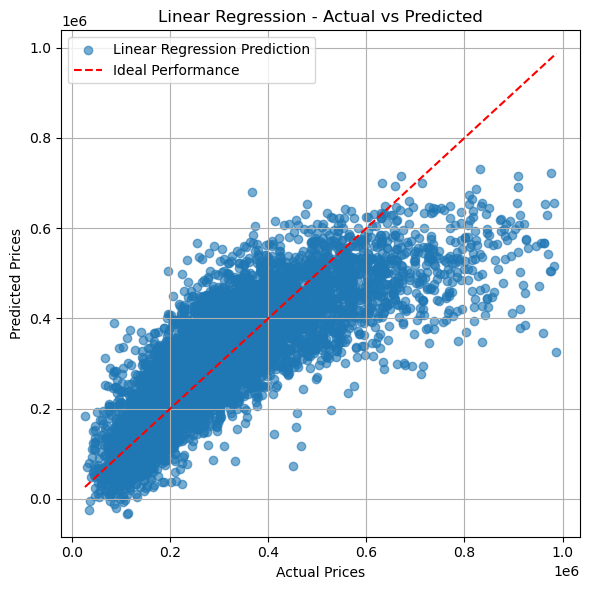

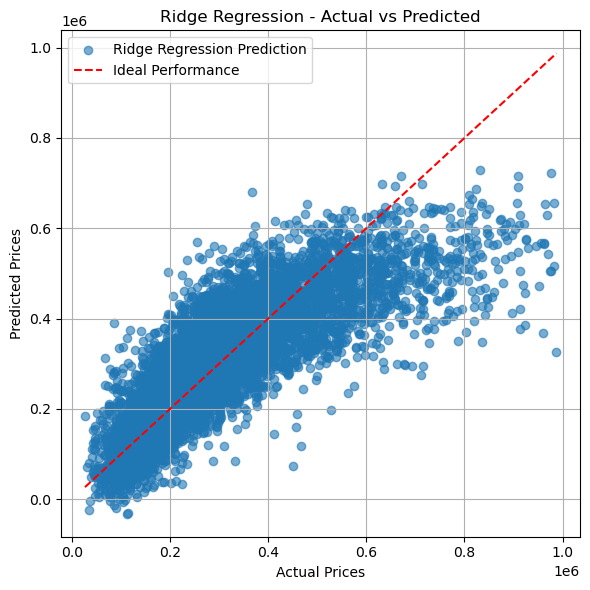

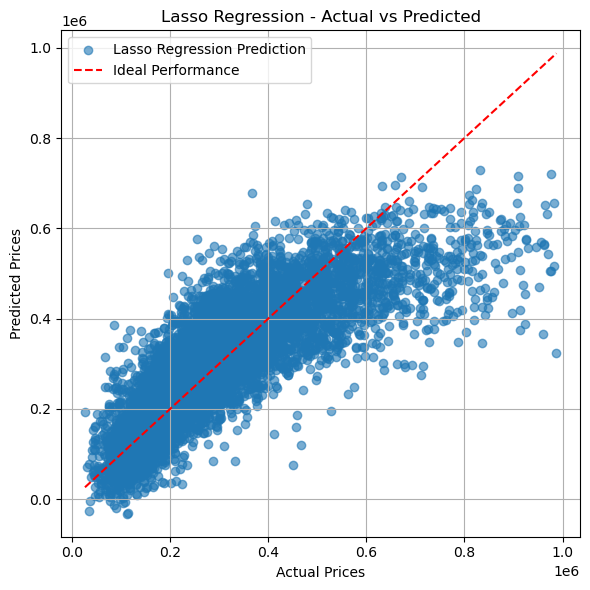

In [13]:
def plot_predicted_vs_actual(ytest, y_pred, title):
    "A function that shows what a model predicts vs the actual value. The parameters it takes in are the predicted values, the actual values, and a string for the title of the graph"
    plt.figure(figsize=(6, 6))
    plt.scatter(ytest, y_pred, alpha=0.6, label='{} Prediction'.format(title))
    plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'r--',label='Ideal Performance')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title('{} - Actual vs Predicted'.format(title))
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()
#Plots the actual vs predicted values for each model
plot_predicted_vs_actual(ytest, y_pred_Linear, "Linear Regression")
plot_predicted_vs_actual(ytest, y_pred_Ridge, "Ridge Regression")
plot_predicted_vs_actual(ytest, y_pred_Lasso, "Lasso Regression")

Overall, it's clear the three models perform fairly well at predicting prices up to roughly £500000. However, beyond that point, they begin to predict prices ranging from £450000-£700000 for houses that can cost almost £1000000. Judging from the density of the data points present, there are significantly more houses that are priced from £0-£500000 than £500000-£1000000 meaning that the models were likely trained to better predict the lower ranges prices than the higher. This could be due to two factors. The first is that the data preparation process earlier could have removed a significant number of higher priced houses unintentionally causing a bias in the remaining train and test sets. However, as previously discussed, this is confirmed to be a moot point as evidently no notable bias was caused by that stage. The second and more likely reason is that there are more houses in England that fall within the lower range which therefore means that a bias is built into the data set. All models sometimes predict negative prices which is an impossible outcome; indicating a slightly poor fit for very low-value homes. 

In comparison to each other, all the models appear visually identical to one another. To get a more granular view of the models, multiple metrics have been used to evaluate each one. R² indicates the proportion of variance in the target variable explained by the model. A higher R² means better fit.  Root Mean Squared Error (RMSE) which measures the square root of the average squared difference between predicted and actual values and is preferred over Mean Squared Error for interpretability as it shares the same unit as the target variable. Lower RMSE means a better fit. Mean Absolute Error (MAE) is the average of the absolute difference between the predicted and actual values with a lower MAE indicating a better fit. MAE will be a key metric throughout this report due to it being robust against any remaining outliers leftover from the data preparation stage as well as it being a very clear metric on how far off predictions will be for stakeholders that use the model.

In [14]:
#Prints the R², RMSE and MAE scores for each model
print('-----------------------')
print('Linear Regression')
print('R²:{:.5f}'.format(r2_score(ytest, y_pred_Linear)))
print('RMSE:{:.3f}'.format(np.sqrt(mean_squared_error(ytest, y_pred_Linear))))
print('MAE:{:.3f}'.format(mean_absolute_error(ytest, y_pred_Linear)))
print('-----------------------')
print('Ridge Regression')
print('R²:{:.5f}'.format(r2_score(ytest, y_pred_Ridge)))
print('RMSE:{:.3f}'.format(np.sqrt(mean_squared_error(ytest, y_pred_Ridge))))
print('MAE:{:.3f}'.format(mean_absolute_error(ytest, y_pred_Ridge)))
print('-----------------------')
print('Lasso Regression')
print('R²:{:.5f}'.format(r2_score(ytest, y_pred_Lasso)))
print('RMSE:{:.3f}'.format(np.sqrt(mean_squared_error(ytest, y_pred_Lasso))))
print('MAE:{:.3f}'.format(mean_absolute_error(ytest, y_pred_Lasso)))
print('-----------------------')

-----------------------
Linear Regression
R²:0.67059
RMSE:92686.872
MAE:66633.061
-----------------------
Ridge Regression
R²:0.67056
RMSE:92691.301
MAE:66632.059
-----------------------
Lasso Regression
R²:0.67036
RMSE:92719.377
MAE:66640.545
-----------------------


The performance metrics across the three models are nearly identical, suggesting that regularisation had minimal impact in this case. All models achieved an R² score of approximately 0.670, meaning they captured about 67% of the variance in house prices. RMSE values were also closely aligned, ranging from 92,687 for Linear Regression to 92,719 for Lasso, while MAE varied only slightly, with Ridge achieving the lowest at 66,632. These marginal differences imply that the dataset may not suffer significantly from multicollinearity or overfitting, and that the added complexity of regularisation did not yield meaningful improvements in predictive performance. This is probably because the initial alphas (regularisation strength) chosen for the models was too small which will be looked into further during the model tuning section.

## Model evaluation:

To evaluate these models further, cross-validation was utilised. All models were evaluated using 5-fold cross-validation to ensure results were not dependent on a single train-test split. This method provides a more robust estimate of model generalisation.

A residual plot was produced for each model, plotting residuals against cross-validated prediction values. 

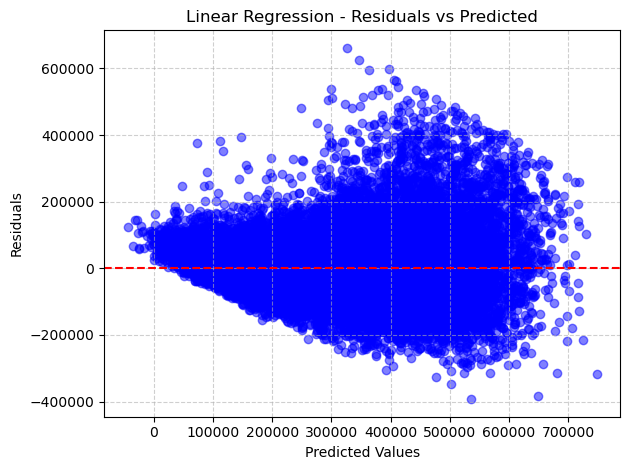

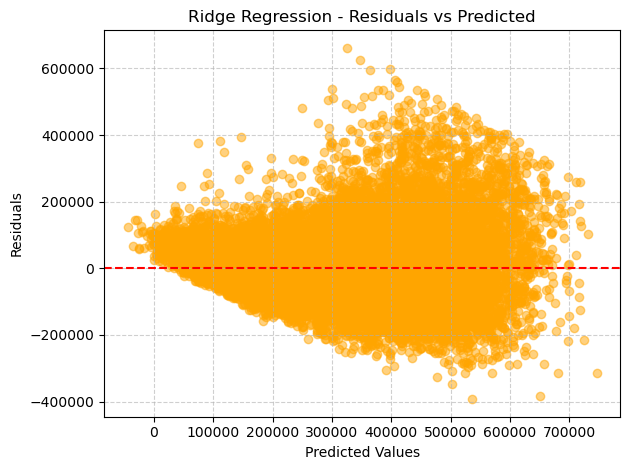

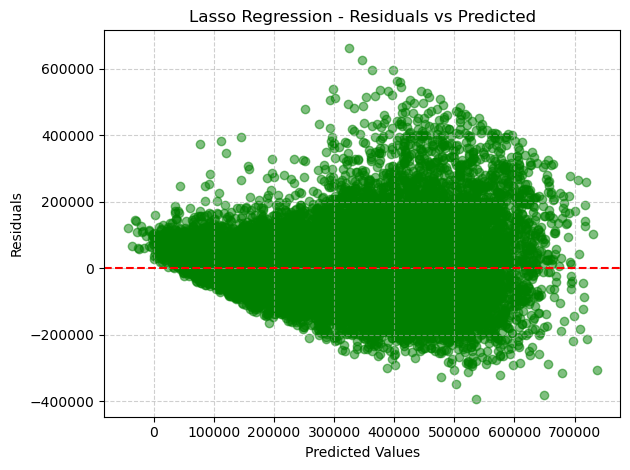

In [15]:
#Sets up Kfold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# Generate cross-validated predictions
Linear_predictions = cross_val_predict(Linear_model, final_features, final_targets, cv=cv)
Ridge_predictions = cross_val_predict(Ridge_model, final_features, final_targets, cv=cv)
Lasso_predictions = cross_val_predict(Lasso_model, final_features, final_targets, cv=cv)

# Calculate residuals
lin_residuals = final_targets - Linear_predictions
ridge_residuals = final_targets - Ridge_predictions
lasso_residuals = final_targets - Lasso_predictions


# Function to plot predicted values vs residuals
def plot_model_diagnostics(predictions, residuals, model_name, color):
    "Function to plot predicted values vs residuals, where the user must specificy the name and colour of the points they want"
    # Residuals vs Predicted
    plt.scatter(predictions, residuals, alpha=0.5, color=color)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Predicted Values')  
    plt.ylabel('Residuals')
    plt.title('{} - Residuals vs Predicted'.format(model_name))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Plot diagnostics for each model
plot_model_diagnostics(Linear_predictions, lin_residuals, "Linear Regression", 'blue')
plot_model_diagnostics(Ridge_predictions, ridge_residuals, "Ridge Regression", 'orange')
plot_model_diagnostics(Lasso_predictions, lasso_residuals, "Lasso Regression", 'green')

All three model plots appear to be virtually identical at this scale, reinforcing how similarly they all perform. Ideally, these points would stay consistently around 0 (illustrated on the graphs with a red dashed line), however this is evidently not the case. The plots revealed a funnel-shaped pattern, indicating that the variance of errors increased with predicted value. This violates one of the assumptions of linear regression and suggests the model is under-performing for higher-priced homes which is to be expected considering the actual vs predicted graphs produced in the previous section. This residual plot also suggests that a simple linear regression model might not be the best fit for this data due to the presence of non-constant variance.

To get more detailed view of the effect cross-validation has had, both R² score and MAE were remeasured using cross validation.

In [16]:
#make MAE scorer
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
# Set up cross-validation


# Linear Regression R² and MAE
lin_cv_r2 = cross_val_score(Linear_model, final_features, final_targets, cv=cv, scoring='r2')
lin_cv_mae = cross_val_score(Linear_model, final_features, final_targets, cv=cv, scoring=mae_scorer)

# Ridge Regression R² and MAE
ridge_cv_r2 = cross_val_score(Ridge_model, final_features, final_targets, cv=cv, scoring='r2')
ridge_cv_mae = cross_val_score(Ridge_model, final_features, final_targets, cv=cv, scoring=mae_scorer)

# Lasso Regression R² and MAE
lasso_cv_r2 = cross_val_score(Lasso_model, final_features, final_targets, cv=cv, scoring='r2')
lasso_cv_mae = cross_val_score(Lasso_model, final_features, final_targets, cv=cv, scoring=mae_scorer)

# Print results with mean ± standard deviation
print("Linear Regression: Mean R² = {:.5f} ± {:.5f} | MAE = {:.4f} ± {:.4f}".format(
    lin_cv_r2.mean(), lin_cv_r2.std(), -lin_cv_mae.mean(), lin_cv_mae.std()))

print("Ridge Regression:  Mean R² = {:.5f} ± {:.5f} | MAE = {:.4f} ± {:.4f}".format(
    ridge_cv_r2.mean(), ridge_cv_r2.std(), -ridge_cv_mae.mean(), ridge_cv_mae.std()))

print("Lasso Regression:  Mean R² = {:.5f} ± {:.5f} | MAE = {:.4f} ± {:.4f}".format(
    lasso_cv_r2.mean(), lasso_cv_r2.std(), -lasso_cv_mae.mean(), lasso_cv_mae.std()))

Linear Regression: Mean R² = 0.67210 ± 0.00642 | MAE = 66442.4063 ± 601.8578
Ridge Regression:  Mean R² = 0.67211 ± 0.00644 | MAE = 66438.4983 ± 604.3940
Lasso Regression:  Mean R² = 0.67203 ± 0.00649 | MAE = 66437.5284 ± 612.6385


To compare these metrics to the pre-cross validated ones, they have both been plotted on bar charts. These bar charts have been "zoomed in" as on a larger scale, they all look identical.

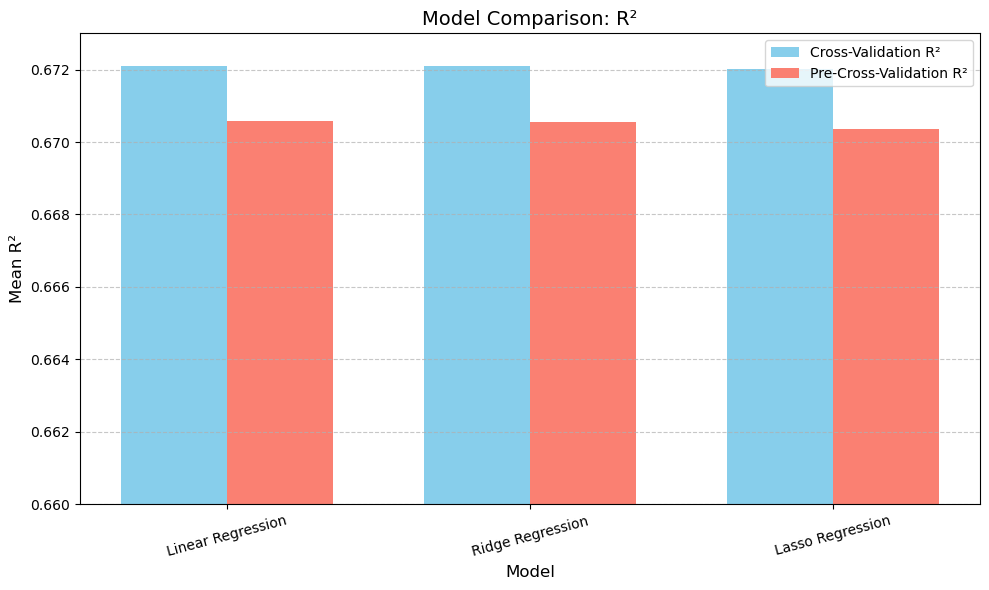

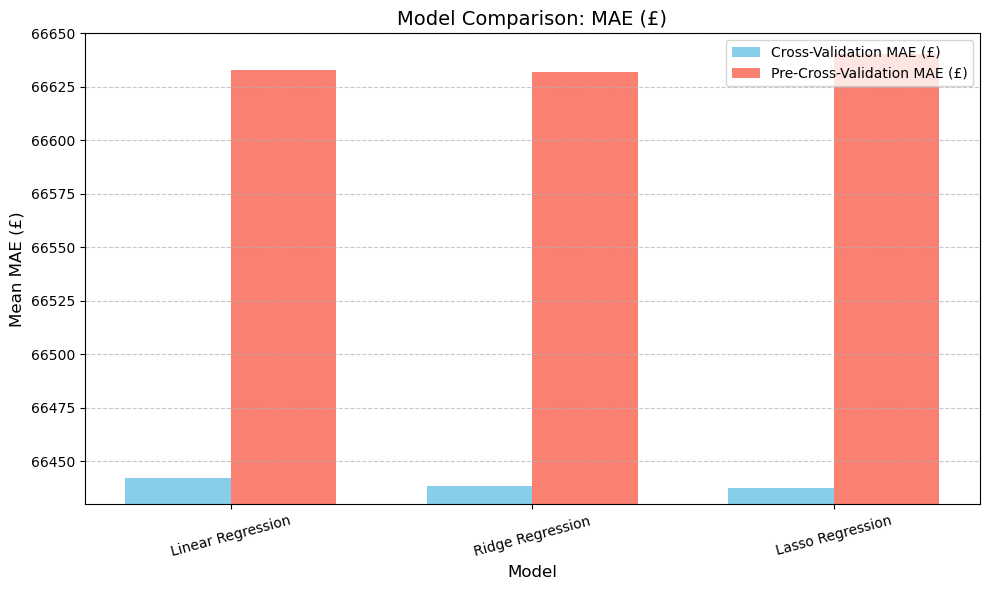

In [17]:
#Values to be used for the bars
models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
mean_r2_cross = [lin_cv_r2.mean(), ridge_cv_r2.mean(), lasso_cv_r2.mean()]
mean_mae_cross = [-lin_cv_mae.mean(), -ridge_cv_mae.mean(), -lasso_cv_mae.mean()]
mean_mae_pre_cross= [mean_absolute_error(ytest, y_pred_Linear),mean_absolute_error(ytest, y_pred_Ridge),mean_absolute_error(ytest, y_pred_Lasso)]
mean_r2_pre_cross= [r2_score(ytest, y_pred_Linear),r2_score(ytest, y_pred_Ridge),r2_score(ytest, y_pred_Lasso)]

r2_score(ytest, y_pred_Lasso)
def metric_comparison(models,cross,pre_cross,bottom_lim,top_lim, metric):
    "Creates a metric comaprison between pre and post cross-validation measurements, allowing for custom limits"
    # Set the width of the bars
    bar_width = 0.35
    
    # Set the positions of the bars on the x-axis
    cross_val_positions = np.arange(len(models))
    pre_cross_val_positions = cross_val_positions + bar_width
    
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(10, 6))  # Adjust figure size as needed
    
    # Create the bars for Cross-Validation 
    cross_val_bars = ax.bar(cross_val_positions, cross, bar_width, label='Cross-Validation {}'.format(metric), color='skyblue')
    # Create the bars for Pre-Cross-Validation 
    pre_cross_val_bars = ax.bar(pre_cross_val_positions, pre_cross, bar_width, label='Pre-Cross-Validation {}'.format(metric), color='salmon')
    
    # plots the labels
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Mean {}'.format(metric), fontsize=12)
    ax.set_title('Model Comparison: {}'.format(metric), fontsize=14)
    ax.set_xticks(cross_val_positions + bar_width / 2)  
    ax.set_xticklabels(models, rotation=15, ha='center', fontsize=10)  
    ax.legend(fontsize=10) 
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(bottom=bottom_lim, top=top_lim)
    plt.tight_layout()
    plt.show()
metric_comparison(models,mean_r2_cross,mean_r2_pre_cross,0.660,0.673, "R²")    
metric_comparison(models,mean_mae_cross,mean_mae_pre_cross,66430,66650, "MAE (£)")



The R² score across all models has been slightly improved, however only by about 0.2%. Likewise, MAE is improved through cross-validation but only by about £200 which is very little on this large a scale. This is to be expected as cross-validation doesn't change the models themselves but evaluates how generalisable the models are. Judging by these metrics, Ridge performs the best in terms of R² score whereas Lasso performs best in terms of MAE. Even though all three perform very similarly, the minute differences are essential to know in order to understand which model is the most optimal. Although the standard deviation of the MAE may seem large, on that scale it represents about 1%.

Separate from cross validation, the models can also be evaluated by seeing how aggressively each reduces its coefficients. This is primarily done to provide a point of reference later on for performing optimal alpha searches for the Ridge and Lasso models. A horizontal bar chart has been created below to show the magnitude of each coefficients' importance for each model.  

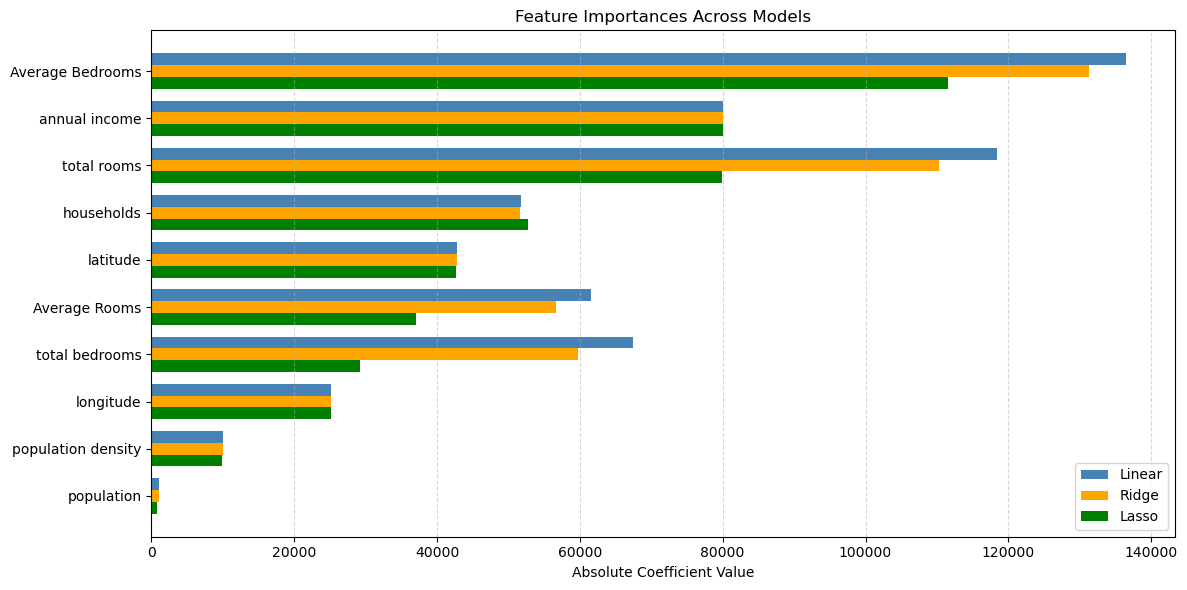

In [18]:
#set up models
lasso_model = Lasso_model.named_steps['lasso']
ridge_model = Ridge_model.named_steps['ridge']
linear_model = Linear_model.named_steps['linearregression']

# Get feature names 
feature_names = Xtrain.columns

# Get absolute coefficients
lasso_coef = np.abs(lasso_model.coef_)
ridge_coef = np.abs(ridge_model.coef_)
linear_coef = np.abs(linear_model.coef_)

# Combine into a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear': linear_coef,
    'Ridge': ridge_coef,
    'Lasso': lasso_coef
}).sort_values(by='Lasso', ascending=False)

# Plot
x = np.arange(len(importance_df))
width = 0.25

plt.figure(figsize=(12, 6))
plt.barh(x - width, importance_df['Linear'], height=width, label='Linear', color='steelblue')
plt.barh(x, importance_df['Ridge'], height=width, label='Ridge', color='orange')
plt.barh(x + width, importance_df['Lasso'], height=width, label='Lasso', color='green')

plt.yticks(x, importance_df['Feature'])
plt.gca().invert_yaxis()
plt.xlabel('Absolute Coefficient Value')
plt.title('Feature Importances Across Models')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Features are ranked by importance based on the magnitude of their coefficients for the Lasso regression model, which reflects their influence on the target variable (house price). Notably, Average Bedrooms and Annual Income are consistently among the most influential features across all models, with Linear and Ridge assigning particularly high weights to them. Population and Population density on the other hand are both the least contributing and thereby have faced the most significant reductions. Lasso overall is more aggressive in its reductions however; it does not set any to zero. As well as that, Ridge regression acts very similarly to the base Linear model in terms of reductions. These two aspects highlight the need for model tuning, specifically changing the alpha/reduction strength of the two regression models. From this point on, a linear model without regularisation is omitted as it's clear that it will not be the optimal model and cannot be tuned in the same way as the regularised models.

## Model tuning: 

To evaluate how each model’s performance scales with data availability, we generated learning curves, which plot error as a function of training set size. For each point on the curve, the model was trained on an increasingly large subset of the data (the training set) and evaluated on unseen data (the validation set) using 5-fold cross-validation. The training error reflects how well the model fits the data it was trained on, while the validation error shows how well it generalises to new, unseen samples. In a well-performing model, the training and validation errors converge as the dataset grows. Divergence between the two can indicate overfitting (low training error, high validation error) or underfitting (high errors on both). By examining these curves, the models were assessed on whether they would benefit from more data, increased complexity, or regularisation.

In [19]:
def learning_curve_maker(model, metric, title, yaxis):
    "A function to create learning curves, allowing for user specified metrics, custom title and y-axis labels."
    train_sizes, train_scores, val_scores = learning_curve(model, X=Xtrain, y=ytrain, train_sizes=np.linspace(0.1, 1.0, 10), cv=cv, scoring=metric, shuffle=True, random_state=42)
    
    # Calculate mean and std for plotting
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, -train_scores_mean, label=('Training {}'.format(yaxis)), marker='o')
    plt.plot(train_sizes, -val_scores_mean, label=('Validation {}'.format(yaxis)), marker='s')
    plt.fill_between(train_sizes, -train_scores_mean - train_scores_std, -train_scores_mean + train_scores_std, alpha=0.2)
    plt.fill_between(train_sizes, -val_scores_mean - val_scores_std, -val_scores_mean + val_scores_std, alpha=0.2)
    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel(yaxis)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

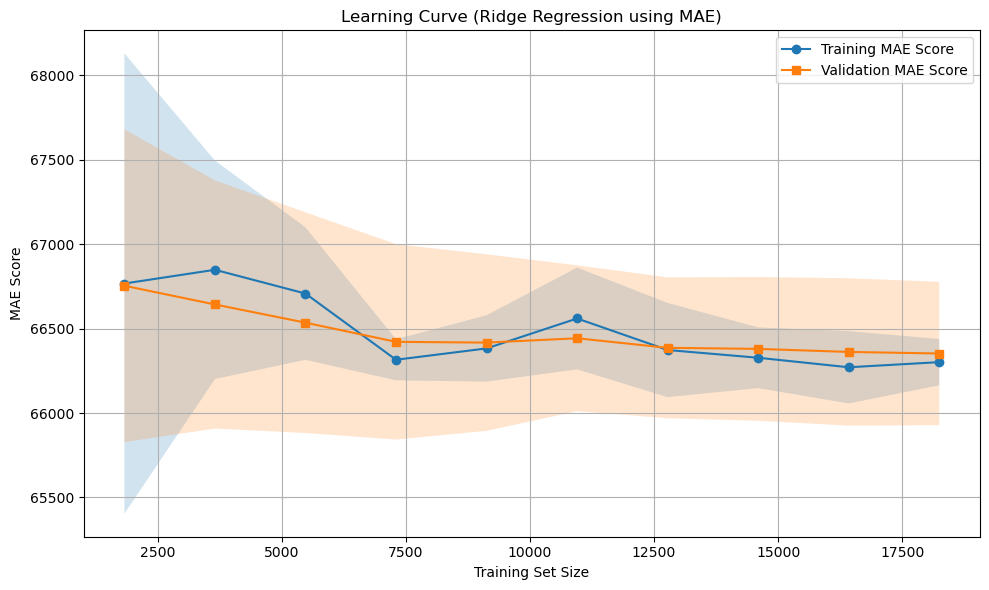

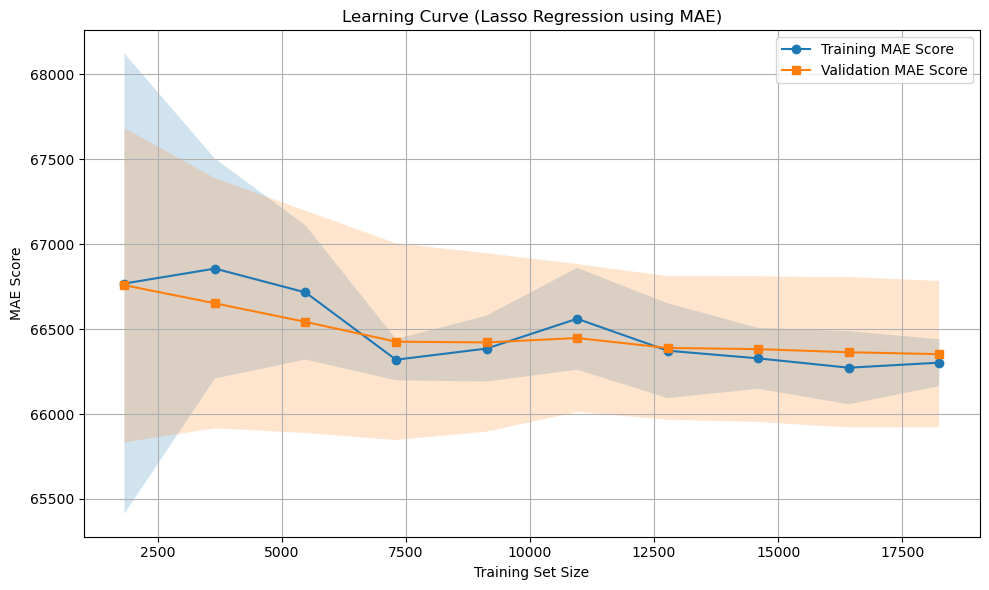

In [20]:
#Plots learning curves
ridge_mae_curve=learning_curve_maker(Ridge_model, 'neg_mean_absolute_error', "Learning Curve (Ridge Regression using MAE)","MAE Score")
lasso_mae_curve=learning_curve_maker(Lasso_model, 'neg_mean_absolute_error', "Learning Curve (Lasso Regression using MAE)","MAE Score")

The two learning curves produced are very similar to each other, likely due to the alphas being the same. Initially, both training and validation MAE are relatively high and exhibit notable variance, as shown by the wide shaded regions representing standard deviation. This may suggest slight underfitting. As the training set size grows, both MAE scores decrease and stabilise, with the gap between training and validation curves narrowing. This convergence suggests that the model benefits from more training data, reducing both bias and variance. The learning curve flattens toward the end, indicating diminishing returns in MAE improvement with additional training samples. 

To efficiently check how different alphas perform for the two regression models, a grid search was performed for both. The grid used was logarithmic ranging from 1e-1 to 1e4 and the same 5-fold cross validation was used, prioritising alphas that provided the best MAE. The model with the best alpha is then set up for later use.

In [21]:
#performs the grid search 
ridge_param_grid = {'ridge__alpha': np.logspace(-1, 4, 6)}
ridge_pipeline = make_pipeline(StandardScaler(), Ridge(max_iter=10000))
grid_ridge = GridSearchCV(ridge_pipeline, ridge_param_grid, scoring=mae_scorer, cv=cv)
grid_ridge.fit(Xtrain, ytrain)
#sets up the optimal model
best_ridge_model = grid_ridge.best_estimator_
best_alpha_mae_ridge = grid_ridge.best_params_['ridge__alpha']
print("The best Alpha for Ridge is {}".format(best_alpha_mae_ridge))


The best Alpha for Ridge is 1000.0


In [22]:
#performs the grid search 
lasso_param_grid = {'lasso__alpha': np.logspace(-1, 4, 6)}
lasso_pipeline = make_pipeline(StandardScaler(), Lasso(max_iter=10000))
grid_lasso = GridSearchCV(lasso_pipeline, lasso_param_grid, scoring=mae_scorer, cv=cv)
grid_lasso.fit(Xtrain, ytrain)
#sets up the optimal model
best_lasso_model = grid_lasso.best_estimator_
best_alpha_mae_lasso = grid_lasso.best_params_['lasso__alpha']
print("The best Alpha for Lasso is {}".format(best_alpha_mae_lasso))


The best Alpha for Lasso is 100.0


These alphas are significantly greater than the initial ones that were chosen. This implies that the original alphas were too small which caused the coefficient reductions to be minimal. To show the effect this has had on the coefficients, a feature importance graph has been produced. 

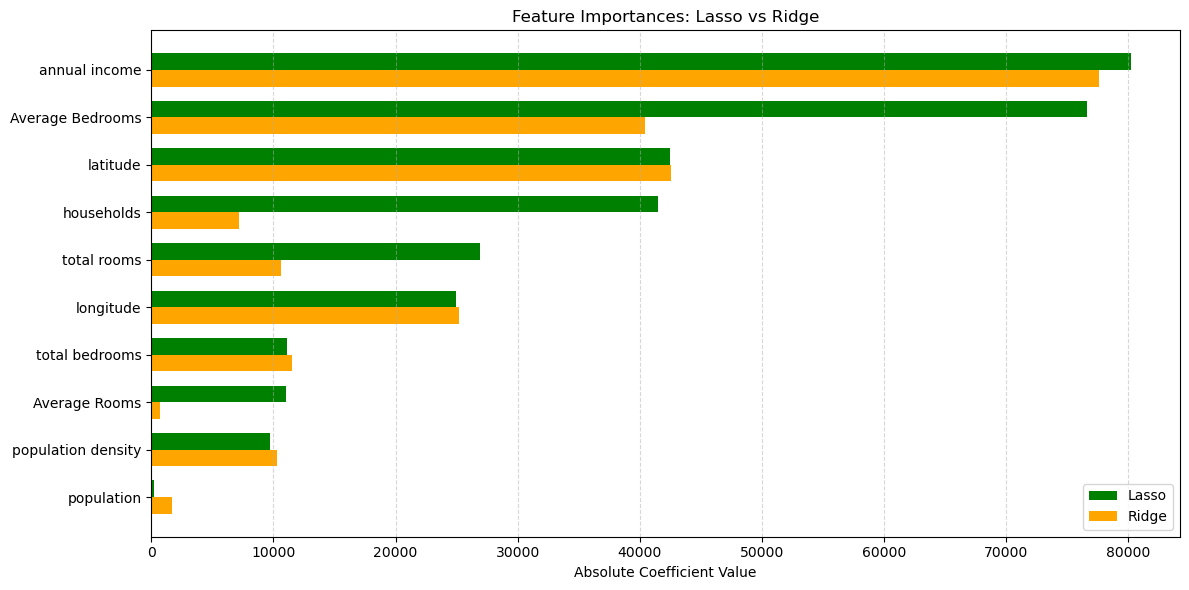

In [23]:
#set up models
ridge_model = best_ridge_model.named_steps['ridge']
lasso_model = best_lasso_model.named_steps['lasso']
#get feature names
feature_names = Xtrain.columns
# Get absolute coefficients
ridge_coef = np.abs(ridge_model.coef_)
lasso_coef = np.abs(lasso_model.coef_)

# Combine into DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Ridge': ridge_coef,
    'Lasso': lasso_coef
}).sort_values(by='Lasso', ascending=False)

# Plot
x = np.arange(len(importance_df))
width = 0.35
plt.figure(figsize=(12, 6))
plt.barh(x - width/2, importance_df['Lasso'], height=width, label='Lasso', color='green')
plt.barh(x + width/2, importance_df['Ridge'], height=width, label='Ridge', color='orange')
plt.yticks(x, importance_df['Feature'])
plt.gca().invert_yaxis()
plt.xlabel('Absolute Coefficient Value')
plt.title('Feature Importances: Lasso vs Ridge')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

As expected, the feature importance across all coefficients has been reduced. Annual income has become the most important feature whilst population and population density remain the least important. Something to note is that latitude has now become the third most important feature, which is likely because houses in the north of England tend to cost noticeably less than those in the south [3]. Another aspect to consider is that Ridge regression has reduced the coefficients much more than Lasso here. This is because the optimal alpha for Ridge regression was ten times larger than for Lasso, thereby increasing the strength of the reductions. 

Now that these alphas have been modified, the MAE can once again be measured. This is done as these should be the best possible scores for both regressions due to the grid search prioritising MAE.

In [24]:
# Ridge Regression MAE with standard deviation
ridge_mae_scores = -cross_val_score(best_ridge_model, final_features, final_targets, cv=cv, scoring=mae_scorer)
print("Ridge Regression MAE: {:.4f} ± {:.4f}".format(ridge_mae_scores.mean(), ridge_mae_scores.std()))

# Lasso Regression MAE with standard deviation
lasso_mae_scores = -cross_val_score(best_lasso_model, final_features, final_targets, cv=cv, scoring=mae_scorer)
print("Lasso Regression MAE: {:.4f} ± {:.4f}".format(lasso_mae_scores.mean(), lasso_mae_scores.std()))

Ridge Regression MAE: 66368.9004 ± 664.3580
Lasso Regression MAE: 66440.1839 ± 635.4749


In comparison to the original cross validated scores, Ridge regression sees a noticeable improvement, achieving the best MAE score yet. However, strangely the new Lasso score is very slightly worse that the initial one despite the alpha being optimised to get the best MAE score for this for this regularisation. This could either be because the model struggles slightly more when dealing cross validation at greater alphas meaning it's not as generalisable or there may simply be an error in the coding.

Finally, learning curves are once again created but this time using the optimal alphas.

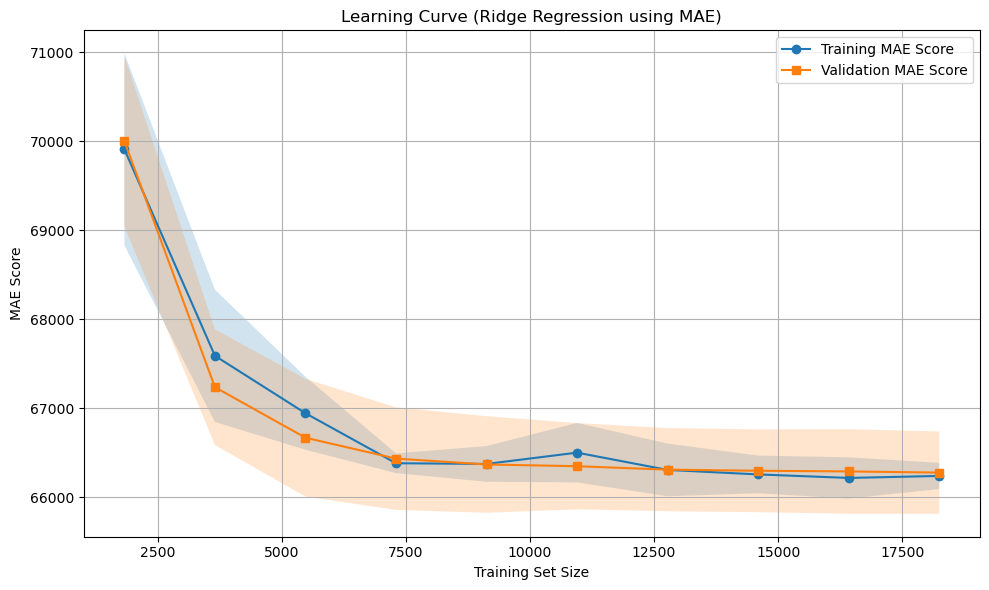

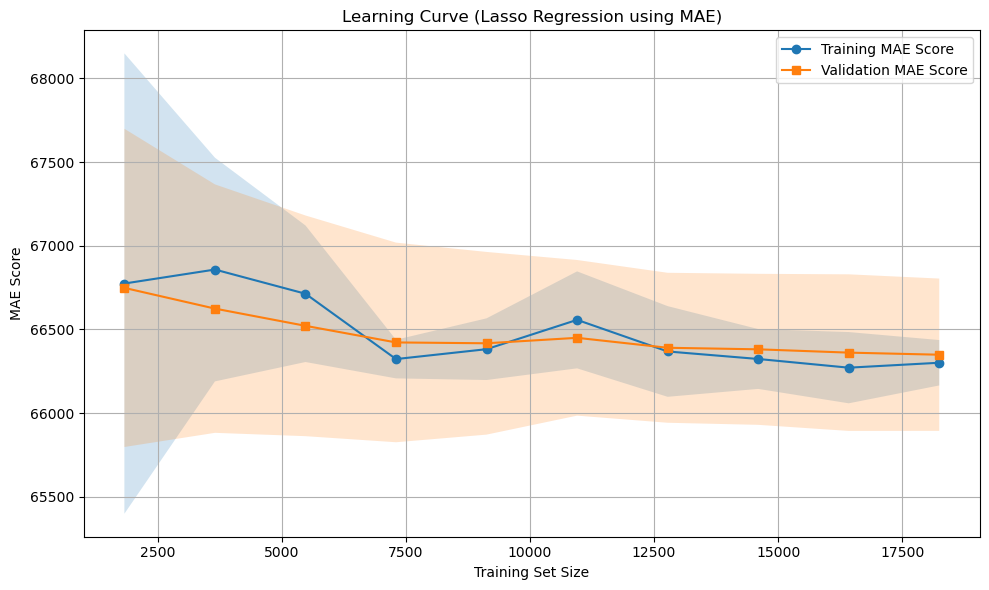

In [25]:
#creates learning curves
ridge_mae_curve=learning_curve_maker(best_ridge_model, 'neg_mean_absolute_error', "Learning Curve (Ridge Regression using MAE)","MAE Score")
lasso_mae_curve=learning_curve_maker(best_lasso_model, 'neg_mean_absolute_error', "Learning Curve (Lasso Regression using MAE)","MAE Score")

The graph for the Lasso model remains unchanged as performance has stayed almost identical. However, the curve for Ridge has changed significantly. It shows a notably steeper initial decline in both training and validation MAE as training set size increases. The performance gains are much more immediate and consistent compared to the first graph. The overall MAE scores begin higher (around £70,000) but drop rapidly and settle below £66,500 with increased data, matching or slightly outperforming the first model's best scores. Moreover, the shaded variance bands are narrower throughout, especially in the larger training sizes, suggesting greater model stability and generalisation. When comparing both Ridge graphs, the second indicates a model that benefits more clearly and predictably from increased data. The clearer trend and reduced variance suggest the model represented in the second graph may be more robust and reliable for practical use.

## Conclusion: 

Overall, this report has shown that a Ridge Regression model with an alpha of 1000 is the best form for a linear model tasked with predicting house prices in England to take. It is able to capture roughly 67% of price variance and has a Mean Absolute Error of £66368.9004 ± £664.3580. While the model works effectively at predicting prices at lower to mid-range values, it begins to fail at higher range values.

To improve the model further, I would recommend switching from a linear model to a non-linear model instead such as Random Forests. This is because a linear model doesn't capture the nuance relationships between certain features such as geography and population However, this would come with a slight loss in interpretability as well as an increased computational cost.. Another aspect that could be looked into is expanding the original data to have even more features. For example, transport link ratings or crime statistics; both factors that have an effect on pricing. This would also work well for a non-linear model, as there would more intricate relationships between the features.


## References:

1) Linda Cremonesi, 2025, HousingEngland.csv, Queen Mary University of London
2) Mathew Keep, 2025, Housing market: Economic indicators, House of Commons Library, Available at:https://commonslibrary.parliament.uk/research-briefings/sn02820/#:~:text=Find%20the%20latest%20data%20on%20house%20prices%2C%20mortgage,be%20found%20on%20the%20main%20Economic%20Indicators%20page.
3) HM Land Registry, 2025, UK House Price Index for December 2024, UK Government, Available at: https://www.gov.uk/government/news/uk-house-price-index-for-december-2024

## Word count

In [27]:
import io
import nbformat

filepath ='FinalProject_2025_UKHousing.ipynb'

with io.open(filepath, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

word_instructions = 35
word_count = 0
for cell in nb.cells:
    if cell.cell_type == "markdown":
        word_count += len(cell['source'].replace('#', '').lstrip().split())
print("The total word count is:", word_count - word_instructions)


The total word count is: 3133
